In [1]:
import os
import warnings
import boto3
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp

#### Functions

In [2]:
# calculate population stability index
def calculate_psi(arr_expected, arr_actual, int_n_bins=10):
    """
    PSI measures how much the distribution of a variable has shifted
    between the development (expected) and production (actual) populations.
    PSI < 0.10: no significant shift
    PSI 0.10-0.25: moderate shift, investigate
    PSI > 0.25: significant shift, action required
    """
    arr_bins = np.linspace(0, 1, int_n_bins + 1)
    arr_expected_counts = np.histogram(arr_expected, bins=arr_bins)[0]
    arr_actual_counts = np.histogram(arr_actual, bins=arr_bins)[0]
    # convert to proportions, avoid zeros
    arr_expected_pct = (arr_expected_counts + 1) / (len(arr_expected) + int_n_bins)
    arr_actual_pct = (arr_actual_counts + 1) / (len(arr_actual) + int_n_bins)
    flt_psi = np.sum((arr_actual_pct - arr_expected_pct) * np.log(arr_actual_pct / arr_expected_pct))
    return flt_psi

In [3]:
# calculate characteristic stability index for all features
def calculate_csi(df_expected, df_actual, list_feature_cols, int_n_bins=10):
    """
    CSI measures feature-level distributional shift. Same thresholds as PSI.
    Applied to each feature individually to identify which inputs have drifted.
    """
    list_rows = []
    for str_col in list_feature_cols:
        arr_expected = df_expected[str_col].dropna().values
        arr_actual = df_actual[str_col].dropna().values
        # use percentile-based bins from expected data
        arr_bins = np.percentile(arr_expected, np.linspace(0, 100, int_n_bins + 1))
        arr_bins = np.unique(arr_bins)
        if len(arr_bins) < 3:
            list_rows.append({'str_feature': str_col, 'flt_csi': 0.0})
            continue
        arr_expected_counts = np.histogram(arr_expected, bins=arr_bins)[0]
        arr_actual_counts = np.histogram(arr_actual, bins=arr_bins)[0]
        int_n = len(arr_bins) - 1
        arr_expected_pct = (arr_expected_counts + 1) / (len(arr_expected) + int_n)
        arr_actual_pct = (arr_actual_counts + 1) / (len(arr_actual) + int_n)
        flt_csi = np.sum((arr_actual_pct - arr_expected_pct) * np.log(arr_actual_pct / arr_expected_pct))
        list_rows.append({'str_feature': str_col, 'flt_csi': flt_csi})
    return pd.DataFrame(list_rows).sort_values('flt_csi', ascending=False)

In [4]:
# plot psi over time periods
def plot_psi_trend(df_data, str_date_col, str_pred_col, arr_baseline, str_train_end, str_valid_end, str_freq='M', str_filename='output/psi_trend.png'):
    df_data = df_data.copy()
    df_data['period'] = df_data[str_date_col].dt.to_period(str_freq).astype(str)
    list_periods = sorted(df_data['period'].unique())
    list_psi = []
    for str_period in list_periods:
        arr_actual = df_data.loc[df_data['period'] == str_period, str_pred_col].values
        if len(arr_actual) > 10:
            list_psi.append({'str_period': str_period, 'flt_psi': calculate_psi(arr_baseline, arr_actual)})
    df_psi = pd.DataFrame(list_psi)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(range(len(df_psi)), df_psi['flt_psi'], color='steelblue', edgecolor='black')
    ax.axhline(y=0.10, color='orange', linestyle='--', linewidth=1.5, label='Moderate (0.10)')
    ax.axhline(y=0.25, color='red', linestyle='--', linewidth=1.5, label='Significant (0.25)')
    # add split boundary lines
    for idx, str_period in enumerate(df_psi['str_period']):
        if str_period == str_train_end:
            ax.axvline(x=idx + 0.5, color='black', linestyle='-', linewidth=2, label='Train End')
        if str_period == str_valid_end:
            ax.axvline(x=idx + 0.5, color='gray', linestyle='-', linewidth=2, label='Validation End')
    ax.set_xticks(range(len(df_psi)))
    ax.set_xticklabels(df_psi['str_period'], rotation=45, ha='right')
    ax.set_title('PSI Over Time', fontsize=16)
    ax.set_xlabel('Period', fontsize=12)
    ax.set_ylabel('PSI', fontsize=12)
    ax.legend(loc='upper right')
    ax.set_ylim(top=max(ax.get_ylim()[1], 0.30) * 1.15)
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()
    return df_psi

In [5]:
# plot csi by feature
def plot_csi(df_csi, str_filename='output/csi_by_feature.png'):
    df_plot = df_csi.sort_values('flt_csi', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(5, len(df_plot) * 0.4)))
    list_colors = ['red' if x > 0.25 else 'orange' if x > 0.10 else 'steelblue' for x in df_plot['flt_csi']]
    ax.barh(df_plot['str_feature'], df_plot['flt_csi'], color=list_colors, edgecolor='black')
    ax.axvline(x=0.10, color='orange', linestyle='--', linewidth=1.5, label='Moderate (0.10)')
    ax.axvline(x=0.25, color='red', linestyle='--', linewidth=1.5, label='Significant (0.25)')
    ax.set_title('CSI by Feature', fontsize=16)
    ax.set_xlabel('CSI', fontsize=12)
    ax.set_ylabel('Feature', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [6]:
# plot target drift over time
def plot_target_drift_over_time(df_data, str_date_col, str_target, str_pred_col, str_train_end, str_valid_end, str_freq='M', str_filename='output/target_drift_over_time.png'):
    df_data = df_data.copy()
    df_data['period'] = df_data[str_date_col].dt.to_period(str_freq).astype(str)
    list_periods = sorted(df_data['period'].unique())
    list_rows = []
    for str_period in list_periods:
        df_period = df_data[df_data['period'] == str_period]
        if len(df_period) > 10:
            list_rows.append({
                'str_period': str_period,
                'flt_actual_rate': df_period[str_target].mean(),
                'flt_predicted_rate': df_period[str_pred_col].mean(),
            })
    df_drift = pd.DataFrame(list_rows)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(range(len(df_drift)), df_drift['flt_actual_rate'], marker='o', color='steelblue', linewidth=2, label='Actual Default Rate')
    ax.plot(range(len(df_drift)), df_drift['flt_predicted_rate'], marker='s', color='salmon', linewidth=2, label='Mean Predicted PD')
    # add split boundary lines
    for idx, str_period in enumerate(df_drift['str_period']):
        if str_period == str_train_end:
            ax.axvline(x=idx + 0.5, color='black', linestyle='-', linewidth=2, label='Train End')
        if str_period == str_valid_end:
            ax.axvline(x=idx + 0.5, color='gray', linestyle='-', linewidth=2, label='Validation End')
    ax.set_xticks(range(len(df_drift)))
    ax.set_xticklabels(df_drift['str_period'], rotation=45, ha='right')
    ax.set_title('Target Drift Over Time', fontsize=16)
    ax.set_xlabel('Period', fontsize=12)
    ax.set_ylabel('Rate', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()
    return df_drift

In [7]:
# plot auc over time
def plot_auc_over_time(df_data, str_date_col, str_target, str_pred_col, str_train_end, str_valid_end, str_freq='M', str_filename='output/auc_over_time.png'):
    df_data = df_data.copy()
    df_data['period'] = df_data[str_date_col].dt.to_period(str_freq).astype(str)
    list_periods = sorted(df_data['period'].unique())
    list_rows = []
    for str_period in list_periods:
        df_period = df_data[df_data['period'] == str_period]
        if len(df_period) > 10 and df_period[str_target].nunique() == 2:
            flt_auc = roc_auc_score(df_period[str_target], df_period[str_pred_col])
            list_rows.append({'str_period': str_period, 'flt_auc': flt_auc})
    df_auc = pd.DataFrame(list_rows)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(range(len(df_auc)), df_auc['flt_auc'], marker='o', color='steelblue', linewidth=2)
    # add split boundary lines
    for idx, str_period in enumerate(df_auc['str_period']):
        if str_period == str_train_end:
            ax.axvline(x=idx + 0.5, color='black', linestyle='-', linewidth=2, label='Train End')
        if str_period == str_valid_end:
            ax.axvline(x=idx + 0.5, color='gray', linestyle='-', linewidth=2, label='Validation End')
    ax.set_xticks(range(len(df_auc)))
    ax.set_xticklabels(df_auc['str_period'], rotation=45, ha='right')
    ax.set_title('AUC Over Time', fontsize=16)
    ax.set_xlabel('Period', fontsize=12)
    ax.set_ylabel('AUC', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()
    return df_auc

In [8]:
# plot calibration degradation over time
def plot_calibration_over_time(df_data, str_date_col, str_target, str_pred_col, str_train_end, str_valid_end, str_freq='M', str_filename='output/calibration_over_time.png'):
    from sklearn.metrics import brier_score_loss
    df_data = df_data.copy()
    df_data['period'] = df_data[str_date_col].dt.to_period(str_freq).astype(str)
    list_periods = sorted(df_data['period'].unique())
    list_rows = []
    for str_period in list_periods:
        df_period = df_data[df_data['period'] == str_period]
        if len(df_period) > 10:
            flt_brier = brier_score_loss(df_period[str_target], df_period[str_pred_col])
            list_rows.append({'str_period': str_period, 'flt_brier': flt_brier})
    df_brier = pd.DataFrame(list_rows)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(range(len(df_brier)), df_brier['flt_brier'], marker='o', color='steelblue', linewidth=2)
    # add split boundary lines
    for idx, str_period in enumerate(df_brier['str_period']):
        if str_period == str_train_end:
            ax.axvline(x=idx + 0.5, color='black', linestyle='-', linewidth=2, label='Train End')
        if str_period == str_valid_end:
            ax.axvline(x=idx + 0.5, color='gray', linestyle='-', linewidth=2, label='Validation End')
    ax.set_xticks(range(len(df_brier)))
    ax.set_xticklabels(df_brier['str_period'], rotation=45, ha='right')
    ax.set_title('Brier Score Over Time (Calibration Degradation)', fontsize=16)
    ax.set_xlabel('Period', fontsize=12)
    ax.set_ylabel('Brier Score', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()
    return df_brier

In [9]:
# plot kde of predictions over time
def plot_kde_over_time(df_data, str_date_col, str_pred_col, str_freq='Q', str_filename='output/kde_over_time.png'):
    warnings.filterwarnings('ignore')
    df_data = df_data.copy()
    df_data['period'] = df_data[str_date_col].dt.to_period(str_freq).astype(str)
    list_periods = sorted(df_data['period'].unique())
    fig, ax = plt.subplots(figsize=(12, 5))
    for str_period in list_periods:
        arr_pred = df_data.loc[df_data['period'] == str_period, str_pred_col].values
        if len(arr_pred) > 10:
            flt_median = np.median(arr_pred)
            sns.kdeplot(arr_pred, ax=ax, linewidth=1.5, label=f'{str_period} (Median={flt_median:.4f})', alpha=0.7)
    ax.set_title('KDE of Predictions Over Time', fontsize=16)
    ax.set_xlabel('Predicted Probability', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()
    warnings.filterwarnings('default')

#### Constants

In [10]:
# bucket
str_bucket = os.getcwd().split('/')[4].replace('_', '-')
print(f'Bucket: {str_bucket}')

# step
str_step = os.getcwd().split('/')[-1]
print(f'Step: {str_step}')

# s3 paths
str_s3_clean = f's3://{str_bucket}/03_preprocessing'
str_s3_raw = f's3://{str_bucket}/02_data_split'
print(f'S3 Clean: {str_s3_clean}')
print(f'S3 Raw: {str_s3_raw}')

# target
str_target = 'default_12m'
print(f'Target: {str_target}')

# date column
str_date_col = 'origination_date'
print(f'Date Column: {str_date_col}')

# model and feature columns
str_model_path = '../04_model/output/xgboost_model.joblib'
str_feature_cols_path = '../04_model/output/feature_cols.joblib'

# output directory
os.makedirs('output', exist_ok=True)

Bucket: credit-risk-claude
Step: 07_monitoring
S3 Clean: s3://credit-risk-claude/03_preprocessing
S3 Raw: s3://credit-risk-claude/02_data_split
Target: default_12m
Date Column: origination_date


#### Read Data and Model

In [11]:
# read clean data for predictions
df_train_clean = pd.read_parquet(f'{str_s3_clean}/df_train_clean.parquet')
df_valid_clean = pd.read_parquet(f'{str_s3_clean}/df_valid_clean.parquet')
df_test_clean = pd.read_parquet(f'{str_s3_clean}/df_test_clean.parquet')

# read raw splits for date column
df_train_raw = pd.read_parquet(f'{str_s3_raw}/df_train.parquet')
df_valid_raw = pd.read_parquet(f'{str_s3_raw}/df_valid.parquet')
df_test_raw = pd.read_parquet(f'{str_s3_raw}/df_test.parquet')

# load model and feature columns
model = joblib.load(str_model_path)
list_feature_cols = joblib.load(str_feature_cols_path)

print(f'Train: {df_train_clean.shape}')
print(f'Validation: {df_valid_clean.shape}')
print(f'Test: {df_test_clean.shape}')
print(f'Features: {len(list_feature_cols)}')

Train: (17715, 20)
Validation: (3796, 20)
Test: (3797, 20)
Features: 12


/home/ec2-user/anaconda3/envs/tensorflow2_p310/lib/python3.12/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


#### Generate Predictions

The training set serves as the baseline (development) population. The test set simulates production data for monitoring. In a live environment, this would be replaced with actual production scoring data.

In [12]:
# generate predictions for all splits
arr_pred_train = model.predict_proba(df_train_clean[list_feature_cols].values)[:, 1]
arr_pred_valid = model.predict_proba(df_valid_clean[list_feature_cols].values)[:, 1]
arr_pred_test = model.predict_proba(df_test_clean[list_feature_cols].values)[:, 1]

# build monitoring dataframes with date, target, and predictions
df_train = pd.DataFrame({
    str_date_col: pd.to_datetime(df_train_raw[str_date_col].values),
    str_target: df_train_clean[str_target].values,
    'flt_pred': arr_pred_train,
})
df_valid = pd.DataFrame({
    str_date_col: pd.to_datetime(df_valid_raw[str_date_col].values),
    str_target: df_valid_clean[str_target].values,
    'flt_pred': arr_pred_valid,
})
df_test = pd.DataFrame({
    str_date_col: pd.to_datetime(df_test_raw[str_date_col].values),
    str_target: df_test_clean[str_target].values,
    'flt_pred': arr_pred_test,
})

# combine all splits for time-series plots
df_all = pd.concat([df_train, df_valid, df_test], ignore_index=True)

# split boundary dates for vertical lines
str_train_end = df_train[str_date_col].max().strftime('%Y-%m')
str_valid_end = df_valid[str_date_col].max().strftime('%Y-%m')
print(f'Train end: {str_train_end}')
print(f'Validation end: {str_valid_end}')

# baseline predictions from training data
arr_baseline_pred = df_train['flt_pred'].values
print(f'Baseline median PD: {np.median(arr_baseline_pred):.4f}')
print(f'Test median PD: {np.median(df_test["flt_pred"]):.4f}')

Train end: 2024-02
Validation end: 2024-07
Baseline median PD: 0.1286
Test median PD: 0.1293


#### Population Stability Index (PSI)

PSI measures how much the distribution of predicted probabilities has shifted between development and production. It is the most widely used metric for model monitoring in credit risk.
- PSI < 0.10: no significant shift
- PSI 0.10 - 0.25: moderate shift, investigate
- PSI > 0.25: significant shift, action required

In [13]:
# overall psi
flt_psi = calculate_psi(arr_baseline_pred, df_test['flt_pred'].values)
print(f'Overall PSI: {flt_psi:.4f}')
if flt_psi < 0.10:
    print('Status: No significant shift')
elif flt_psi < 0.25:
    print('Status: Moderate shift - investigate')
else:
    print('Status: Significant shift - action required')

Overall PSI: 0.0011
Status: No significant shift


#### PSI Over Time

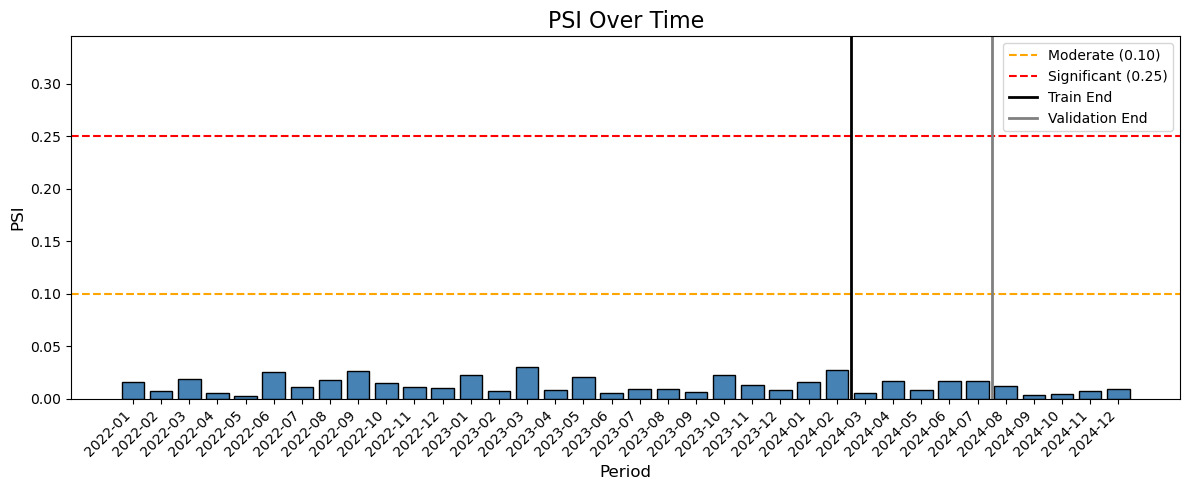

In [14]:
df_psi_trend = plot_psi_trend(df_all, str_date_col, 'flt_pred', arr_baseline_pred, str_train_end, str_valid_end)

#### Characteristic Stability Index (CSI)

CSI applies the same stability calculation to each individual feature, identifying which inputs have drifted the most. Features with high CSI should be investigated for data quality issues or population changes.

In [15]:
df_csi = calculate_csi(df_train_clean, df_test_clean, list_feature_cols)
df_csi.to_csv('output/csi_by_feature.csv', index=False)
df_csi

,str_feature,flt_csi
8,utilization,0.004429
2,employment_length_years,0.003874
3,stated_income,0.003239
11,channel,0.003134
9,inquiries_6m,0.001431
5,bureau_score,0.001218
0,loan_amount,0.001172
6,open_trades,0.000970
1,term_months,0.000687
10,public_records,0.000036


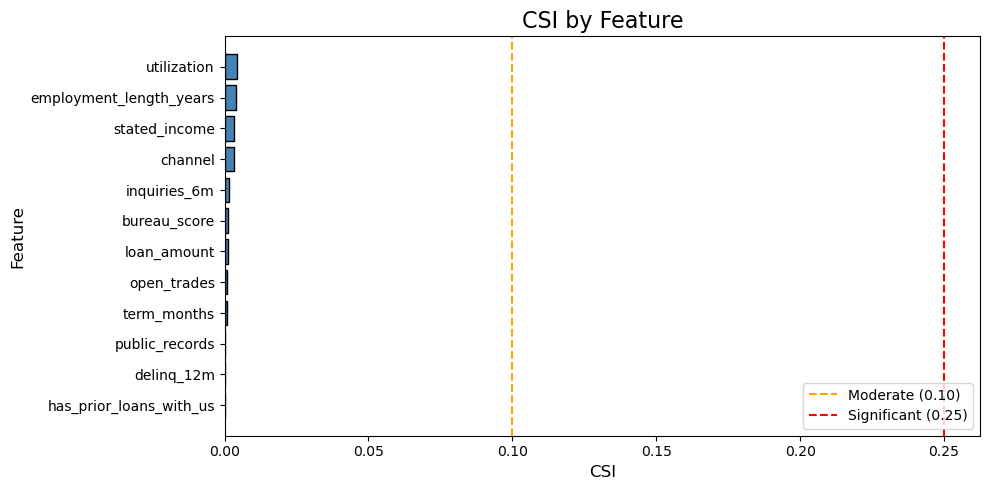

In [16]:
plot_csi(df_csi)

#### Target Drift Over Time

Comparing actual default rates against mean predicted PD over time. Divergence between the two indicates calibration degradation, meaning the model's probability estimates no longer reflect true default likelihood.

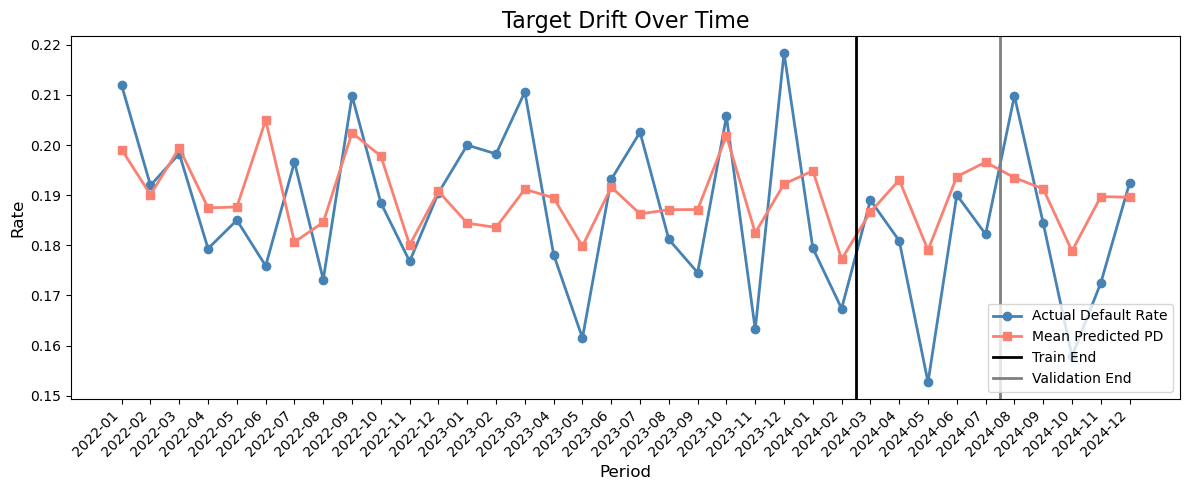

In [17]:
df_target_drift = plot_target_drift_over_time(df_all, str_date_col, str_target, 'flt_pred', str_train_end, str_valid_end)

#### AUC Over Time

Tracking model discrimination over time. A declining AUC indicates the model's ability to rank-order risk is degrading, which may signal the need for retraining.

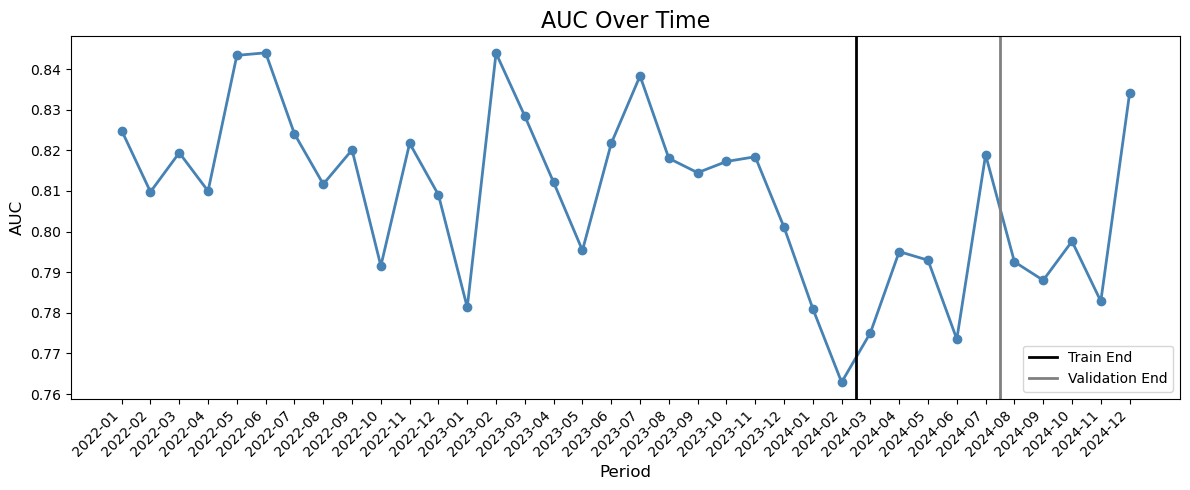

In [18]:
df_auc_trend = plot_auc_over_time(df_all, str_date_col, str_target, 'flt_pred', str_train_end, str_valid_end)

#### Calibration Over Time

Tracking Brier score over time. An increasing Brier score indicates calibration is degrading, meaning predicted probabilities are becoming less accurate estimates of true default likelihood.

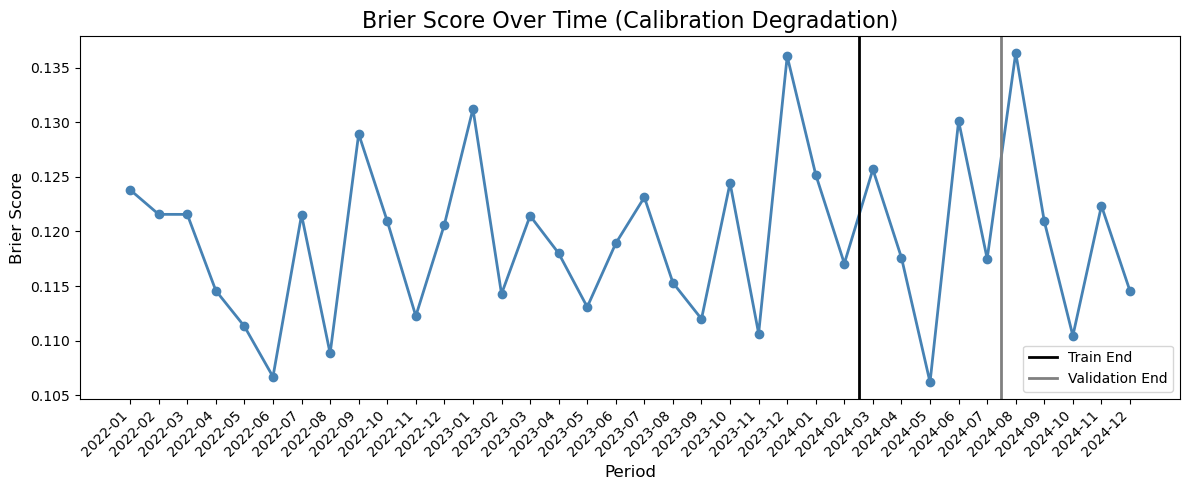

In [19]:
df_brier_trend = plot_calibration_over_time(df_all, str_date_col, str_target, 'flt_pred', str_train_end, str_valid_end)

#### KDE of Predictions Over Time

Visualizing how the distribution of predictions shifts across time periods. Stable distributions indicate the model is behaving consistently.

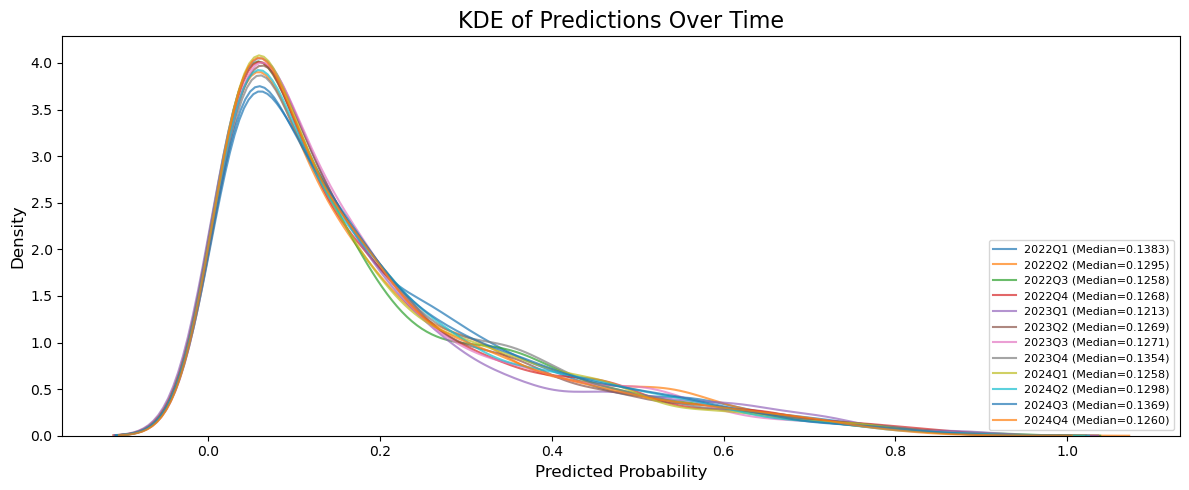

In [20]:
plot_kde_over_time(df_all, str_date_col, 'flt_pred')

#### Monitoring Summary

In [21]:
# save monitoring summary
dict_summary = {
    'flt_psi': flt_psi,
    'flt_baseline_median_pd': np.median(arr_baseline_pred),
    'flt_production_median_pd': np.median(df_test['flt_pred']),
    'flt_baseline_target_mean': df_train[str_target].mean(),
    'flt_production_target_mean': df_test[str_target].mean(),
    'int_n_features_csi_moderate': len(df_csi[df_csi['flt_csi'] > 0.10]),
    'int_n_features_csi_significant': len(df_csi[df_csi['flt_csi'] > 0.25]),
}
df_summary = pd.DataFrame([dict_summary])
df_summary.to_csv('output/monitoring_summary.csv', index=False)
df_summary

,flt_psi,flt_baseline_median_pd,flt_production_median_pd,flt_baseline_target_mean,flt_production_target_mean,int_n_features_csi_moderate,int_n_features_csi_significant
0,0.00115,0.128605,0.129252,0.189783,0.182513,0,0
